# PULSE PRESSURE AMPLIFICATION
### Shreenandan Sahu | CL24M013

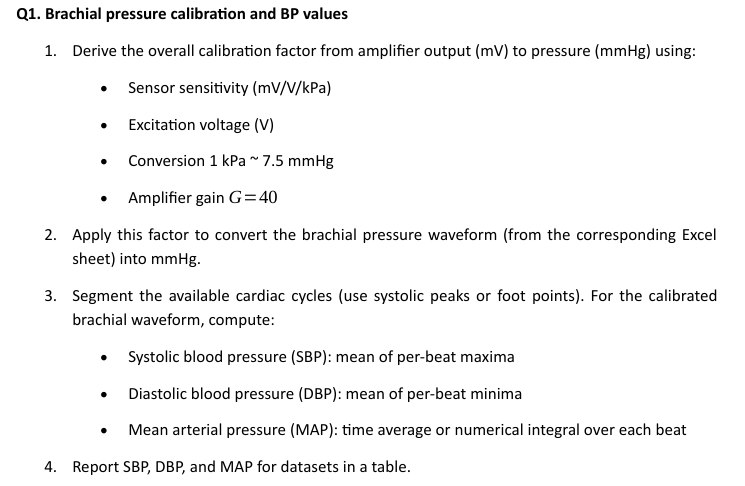

In [161]:
# Gain
G = 40
# Sensitivity
S = 0.5
# Excitation Voltage
Ev = 3.3
# 1Kpa to mmHg
P = 7.5
# Conversion Coefficient relating the output voltage to pressure in mmHg
Cc = G*S*Ev/P
print(Cc)

# Sampling Frequency to time conversion
Fsampling = 250
sampleIndex = 1
t = sampleIndex/Fsampling

# Vout=Cc*Pin
# Pin=(1/Cc)*Vout

8.8


### Importing necessary libraries

In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# pip install openpyxl

In [163]:
# Preparing the Excel Sheet and checking for the sheet names in the files
path = "Assignment_1_all_signals_combined.xlsx"
xls = pd.ExcelFile(path)
print(xls.sheet_names)
sheet_names_list = xls.sheet_names
pressure_sheet_index = [0, 2, 3, 5, 6, 8]
# for i in preussure_sheet_index:
#     print(sheet_names_list[i])

['A_brachial', 'A_carotid', 'A_femoral', 'C_brachial', 'C_carotid', 'C_femoral', 'B_brachial', 'B_carotid', 'B_femoral']


In [164]:
# Filtering Using Moving average filter and then detecting the minima in the signal to track the time points.


# Moving Average Filter
def moving_average(signal: np.ndarray, window_size: int) -> np.ndarray:
    cumsum = np.cumsum(signal)
    moving_avg = np.zeros(len(signal))

    for i in range(len(moving_avg)-window_size+1):
        if i == 0:
            moving_avg[i] = cumsum[i+window_size-1]/window_size
        else:
            moving_avg[i] = (cumsum[i+window_size-1]-cumsum[i-1])/window_size
    moving_avg[-window_size+1:]=signal[-window_size+1:]

    return moving_avg

# Minima Detection (windowed minima)


def min_pressure(pressure: np.ndarray, window=30) -> list:
    timepoints = []
    timepoints.append(np.argmin(pressure[:window]))
    for i in range(window, len(pressure)-window):
        local_window = pressure[i-window:i+window]
        if pressure[i] == np.min(local_window):
            timepoints.append(i)
    timepoints.append(np.argmin(pressure[:-window]))
    return timepoints

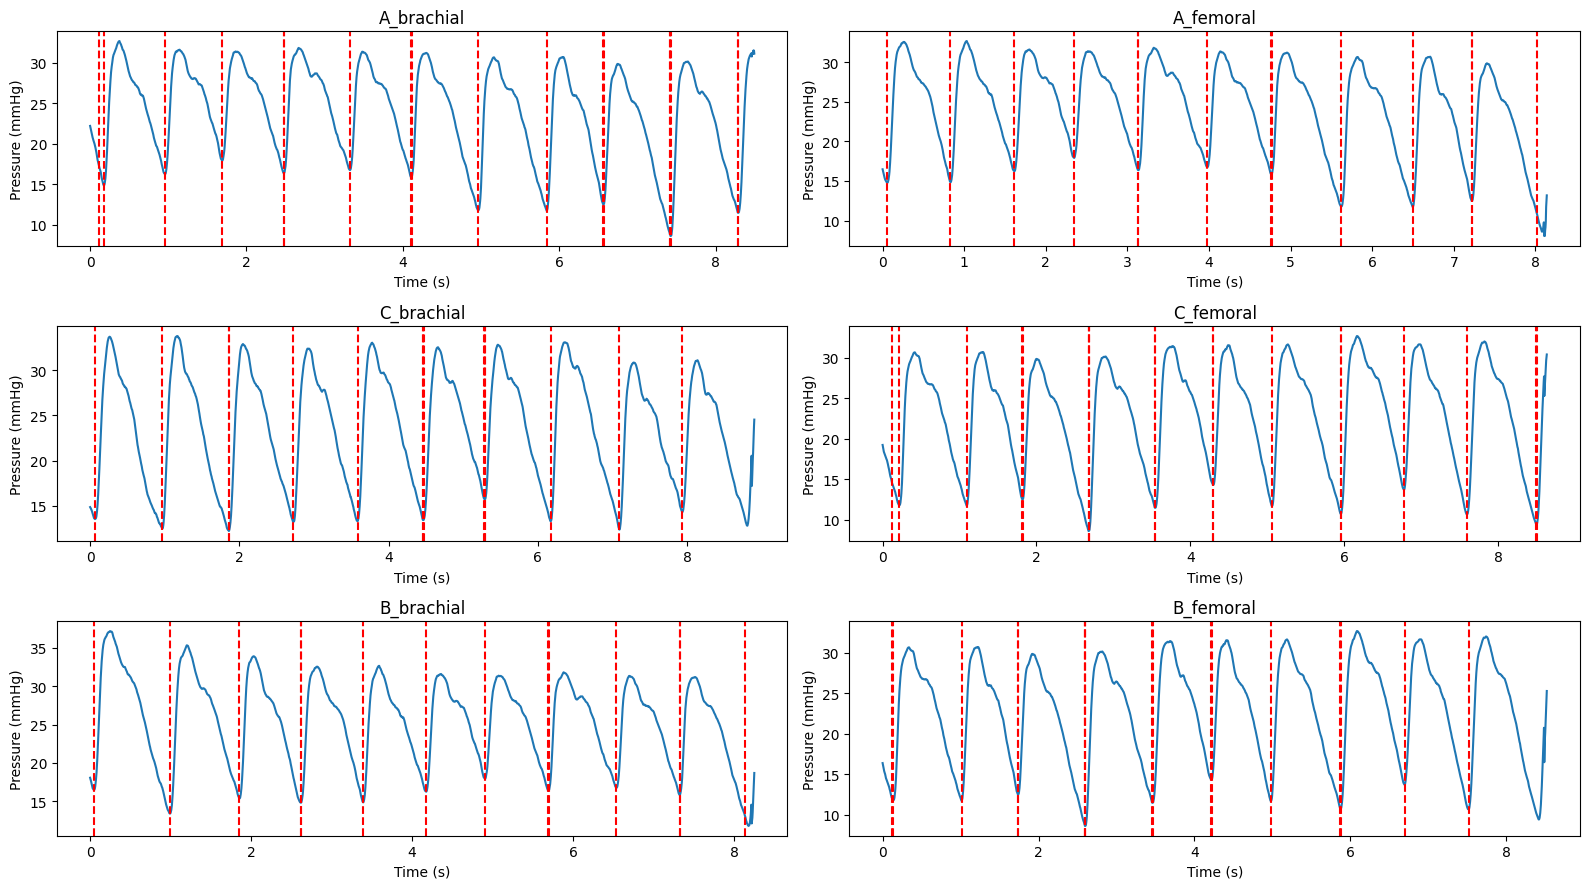

In [165]:
plt.figure(figsize=(16, 9))
for i in pressure_sheet_index:
    df = pd.read_excel(path, sheet_name=sheet_names_list[i])

    pressure = (df.iloc[:, 1])*(1000/Cc)
    pressure = moving_average(pressure, 10)
    time = (df.iloc[:, 0])*(0.004)
    max_pressure_points = min_pressure(pressure)
    plt.subplot(3, 2, (pressure_sheet_index.index(i)+1))
    plt.plot(time, pressure)

    for j in max_pressure_points:
        plt.axvline(x=time[j], color="r", linestyle="--")
    plt.title(sheet_names_list[i])
    plt.xlabel("Time (s)")
    plt.ylabel("Pressure (mmHg)")
    # plt.grid()
plt.tight_layout()

plt.show()

In [166]:
# SBP DBP MAP Calculation

def sbp_dbp_map(pressure: np.ndarray) -> list:
    timepoints = min_pressure(pressure)
    SBP = []
    DBP = []
    MAP123 = []
    MAP = []

    for i in range(1, len(timepoints)-1):
        mini_window = pressure[timepoints[i-1]:timepoints[i]]
        SBP.append(np.max(mini_window))
        DBP.append(np.min(mini_window))
        MAP123.append((2*DBP[-1]+SBP[-1])/3)
        MAP.append(np.sum(mini_window)/len(mini_window))
    return SBP, DBP, MAP123, MAP

In [167]:
print("| SHEET NAME | SBP | DBP | MAP123 | MAP |\n|------|------|------|------|------|")
for i in pressure_sheet_index:
    df=pd.read_excel(path,sheet_name=sheet_names_list[i])
    pressure=(df.iloc[:,1])*(1000/Cc)
    pressure=moving_average(pressure,10)
    sbp, dbp, map123, map = sbp_dbp_map(pressure)
    print(f"| {sheet_names_list[i]} | {np.mean(sbp):.2f} mmHg | {np.mean(dbp):.2f} mmHg | {np.mean(map123):.2f} mmHg | {np.mean(map):.2f} mmHg |")

| SHEET NAME | SBP | DBP | MAP123 | MAP |
|------|------|------|------|------|
| A_brachial | 24.58 mmHg | 13.25 mmHg | 17.02 mmHg | 20.10 mmHg |
| A_femoral | 27.38 mmHg | 14.54 mmHg | 18.82 mmHg | 22.26 mmHg |
| C_brachial | 27.18 mmHg | 13.35 mmHg | 17.96 mmHg | 21.02 mmHg |
| C_femoral | 23.18 mmHg | 10.85 mmHg | 14.96 mmHg | 18.31 mmHg |
| B_brachial | 28.74 mmHg | 15.26 mmHg | 19.75 mmHg | 23.26 mmHg |
| B_femoral | 23.33 mmHg | 11.04 mmHg | 15.14 mmHg | 18.54 mmHg |


| SHEET NAME | SBP | DBP | MAP123 | MAP |
|------|------|------|------|------|
| A_brachial | 24.58 mmHg | 13.25 mmHg | 17.02 mmHg | 20.10 mmHg |
| A_femoral | 27.38 mmHg | 14.54 mmHg | 18.82 mmHg | 22.26 mmHg |
| C_brachial | 27.18 mmHg | 13.35 mmHg | 17.96 mmHg | 21.02 mmHg |
| C_femoral | 23.18 mmHg | 10.85 mmHg | 14.96 mmHg | 18.31 mmHg |
| B_brachial | 28.74 mmHg | 15.26 mmHg | 19.75 mmHg | 23.26 mmHg |
| B_femoral | 23.33 mmHg | 11.04 mmHg | 15.14 mmHg | 18.54 mmHg |

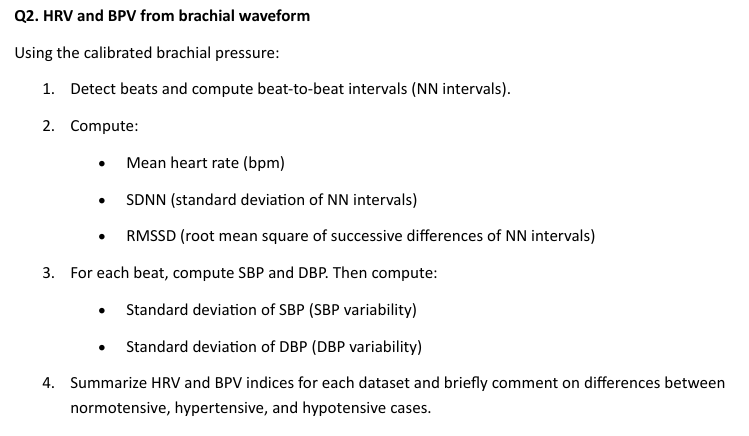

In [168]:
path = "Assignment_1_all_signals_combined.xlsx"
xls = pd.ExcelFile(path)
print(xls.sheet_names)
sheet_names_list = xls.sheet_names
pressure_sheet_index = [0,6,3,]


['A_brachial', 'A_carotid', 'A_femoral', 'C_brachial', 'C_carotid', 'C_femoral', 'B_brachial', 'B_carotid', 'B_femoral']


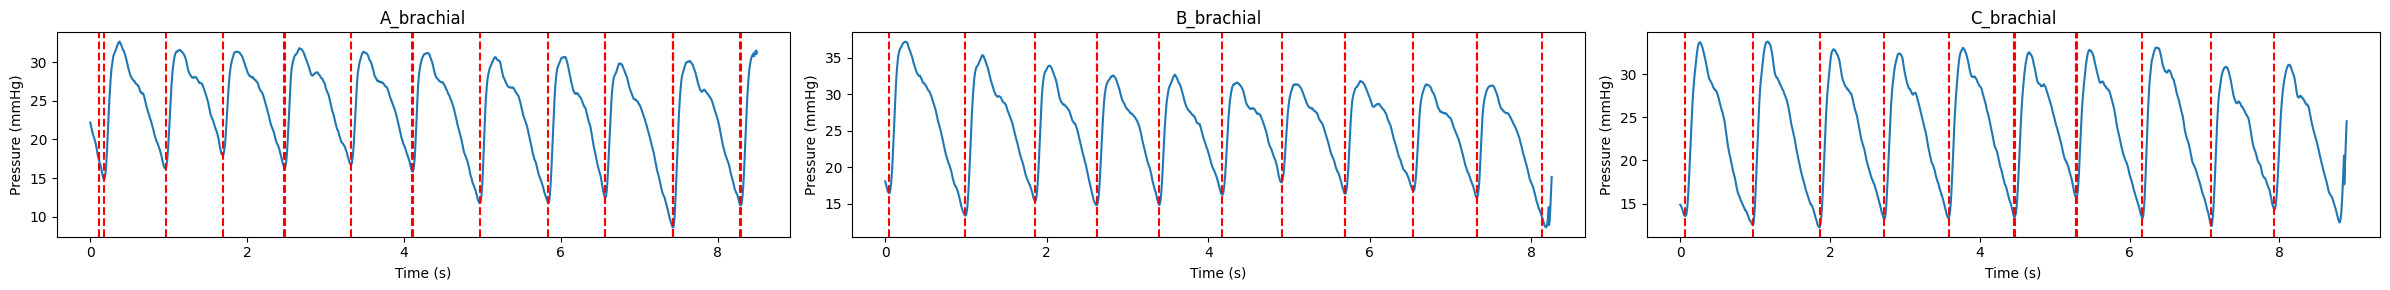

In [169]:
plt.figure(figsize=(24, 3))
for i in pressure_sheet_index:
    df = pd.read_excel(path, sheet_name=sheet_names_list[i])

    pressure = (df.iloc[:, 1])*(1000/Cc)
    pressure = moving_average(pressure, 10)
    time = (df.iloc[:, 0])*(0.004)
    max_pressure_points = min_pressure(pressure)
    plt.subplot(1, 3, (pressure_sheet_index.index(i)+1))
    plt.plot(time, pressure)

    for j in max_pressure_points:
        plt.axvline(x=time[j], color="r", linestyle="--")
    plt.title(sheet_names_list[i])
    plt.xlabel("Time (s)")
    plt.ylabel("Pressure (mmHg)")
    # plt.grid()
plt.tight_layout()

plt.show()

| Metric | Measures                 | Physiological meaning      |
| ------ | ------------------------ | -------------------------- |
| SDNN   | Total variability        | Overall autonomic activity |
| RMSSD  | Beat-to-beat variability | Parasympathetic control    |


In [176]:
print("| SHEET NAME | AVERAGE BEAT INTERVAL (s) | HEART RATE (bpm) | SDNN (ms) | RMSSD (ms) |\n|------|------|------|------|------|")

for i in pressure_sheet_index:
    df = pd.read_excel(path, sheet_name=sheet_names_list[i])
    beat_intervals=[]
    avg_beat_intterval=0
    pressure = (df.iloc[:, 1])*(1000/Cc)
    pressure = moving_average(pressure, 10)
    time = (df.iloc[:, 0])*(0.004)
    min_pressure_points = min_pressure(pressure)
    for j in range(len(min_pressure_points)-1):
        # to avoid fake beat coming due to noise we will limit the minimum time between two beats to be 0.3s (which corresponds to a heart rate of 200 bpm)
        if (time[min_pressure_points[j+1]]-time[min_pressure_points[j]])>0.3: 
            beat_intervals.append(time[min_pressure_points[j+1]]-time[min_pressure_points[j]])
    # print(beat_intervals)
    print(f"| {sheet_names_list[i]} | {np.mean(beat_intervals):.2f} | {60/np.mean(beat_intervals):.2f} | {np.std(beat_intervals)*1000:.2f} | {np.sqrt(np.mean(np.diff(beat_intervals)**2))*1000:.2f} |")





| SHEET NAME | AVERAGE BEAT INTERVAL (s) | HEART RATE (bpm) | SDNN (ms) | RMSSD (ms) |
|------|------|------|------|------|
| A_brachial | 0.81 | 74.11 | 52.34 | 80.52 |
| B_brachial | 0.81 | 74.29 | 59.29 | 58.85 |
| C_brachial | 0.87 | 68.74 | 29.68 | 45.28 |


| SHEET NAME | AVERAGE BEAT INTERVAL (s) | HEART RATE (bpm) | SDNN (ms) | RMSSD (ms) |
|------|------|------|------|------|
| A_brachial | 0.81 | 74.11 | 52.34 | 80.52 |
| B_brachial | 0.81 | 74.29 | 59.29 | 58.85 |
| C_brachial | 0.87 | 68.74 | 29.68 | 45.28 |